# Математика ансамблевых методов

## Ансамбли моделей. Бутстреппинг. Бэггинг

### Задание 2.2
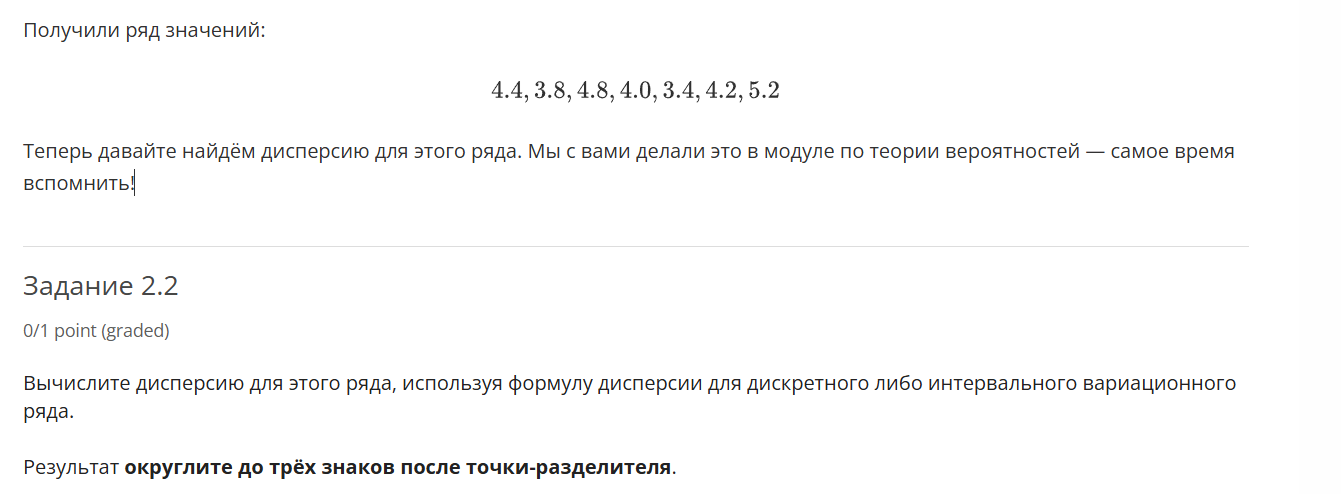

In [15]:
import math

def variance(data, ddof=0):
    n = len(data)
    mean = sum(data) / n
    return sum((x - mean) ** 2 for x in data) / (n - ddof)

data = [4.4, 3.8, 4.8, 4.0, 3.4, 4.2, 5.2]

print(round(variance(data, ddof=0), 3))   # генеральная

0.317


### Задание 2.7

Подготовьте данные к классификации. Условно разделите вино на хорошее и плохое. Хорошим вином будем называть то, параметр quality которого — 6 и более.
Разделите выборку на обучающую и тестовую в соотношении 70/30, в качестве значения параметра random_state возьмите число 42.
Для начала обучите два классификатора: логистическую регрессию (с параметрами по умолчанию) и дерево решений (random_state = 42, максимальная глубина — 10).
1. Введите значение F1-score для классификатора, который показал наилучшее значение. Ответ округлите до трёх знаков после точки-разделителя

In [16]:
#Загружаем неоюходимые библиотеки
import numpy as np 
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [17]:
wine_data = pd.read_csv('data/wineQualityReds.csv')
display(wine_data.head())

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,2,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,3,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,4,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [18]:
#Бинарный признак хорошего вина
wine_data['is_good'] = (wine_data['quality']>=6).astype(int)

#Делаем X и y выборки
X = wine_data.drop(columns=['quality', 'is_good'])
y = wine_data['is_good']

In [19]:
#Разделяем 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y , test_size=0.3, random_state=42
)

In [20]:
#Обучаем логистическую регрессию и выводим F1-score
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print(f"LogReg F1-score: {round(f1_score(y_test, y_pred_log), 3)}")

#Обучаем дерево решений и выводим F1-score
tree_clf = DecisionTreeClassifier(random_state=42, max_depth=10)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

print(f"Tree F1-score: {round(f1_score(y_test, y_pred_tree), 3)}")


LogReg F1-score: 0.739
Tree F1-score: 0.76


c:\Program Files (x86)\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Задание 2.8
Обучите модель с использованием бэггинга (класс BaggingClassifier с random_state=42).

Возьмите из предыдущего задания алгоритм, показавший наилучшее качество, и укажите для него новое количество моделей — 1500. Вычислите новое значение F1-score.

In [22]:
from sklearn.ensemble import BaggingClassifier

bg_clf = BaggingClassifier(
    estimator=tree_clf,
    n_estimators=1500,
    random_state=42
    )

bg_clf.fit(X_train, y_train)
y_pred_bg = bg_clf.predict(X_test)

print(f"BaggingClassifier F1-score: {round(f1_score(y_test, y_pred_bg), 3)}")

BaggingClassifier F1-score: 0.824
